In [ ]:
# =============================================================
# CELL 01 — Check GPU availability
# Confirms we are running on a T4 GPU before proceeding
# =============================================================

import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    print('Current GPU:', gpu)
    if 'T4' in gpu:
        print('✅ You are using a T4 GPU')
    else:
        print('⚠️ GPU detected but not T4 — proceed with caution')
else:
    print('❌ No GPU enabled — go to Runtime > Change runtime type > GPU')

Current GPU: Tesla T4
✅ You are using a T4 GPU


In [ ]:
# =============================================================
# CELL 02 — Mount Google Drive
# All datasets, saved features, models and results live here
# =============================================================

from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted at /content/drive')

Mounted at /content/drive
✅ Drive mounted at /content/drive


In [ ]:
# =============================================================
# CELL 03 — Install required libraries and import all dependencies
# lime   : for model interpretability (LIME explanations)
# librosa: for audio loading and feature extraction
# tqdm   : for progress bars during feature extraction
# =============================================================

!pip install lime --quiet

import os
import numpy as np
import librosa
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dropout, Dense, Bidirectional, LSTM,
    Flatten, Average
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('✅ All libraries imported successfully')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TensorFlow version: 2.19.0
✅ All libraries imported successfully


In [ ]:
# =============================================================
# CELL 04 — Create all required Drive folders for Iteration 2
# Iteration_2 is kept separate from Iteration_1 as backup
# Datasets folder is shared — no need to re-download
# =============================================================

DRIVE_BASE    = '/content/drive/MyDrive/Deep Learning Project'
DATASET_BASE  = '/content/drive/MyDrive/Deep Learning Project/Datasets'
ITER_PATH     = '/content/drive/MyDrive/Deep Learning Project/Iteration_2'
RESULTS_PATH  = '/content/drive/MyDrive/Deep Learning Project/Iteration_2/results'
MODELS_PATH   = '/content/drive/MyDrive/Deep Learning Project/Iteration_2/models'
FEATURES_PATH = '/content/drive/MyDrive/Deep Learning Project/Iteration_2/features'

folders = [
    DRIVE_BASE,
    DATASET_BASE,
    ITER_PATH,
    RESULTS_PATH,
    MODELS_PATH,
    FEATURES_PATH
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'✅ {folder}')

print('\n✅ All Iteration 2 folders created successfully')

✅ /content/drive/MyDrive/Deep Learning Project
✅ /content/drive/MyDrive/Deep Learning Project/Datasets
✅ /content/drive/MyDrive/Deep Learning Project/Iteration_2
✅ /content/drive/MyDrive/Deep Learning Project/Iteration_2/results
✅ /content/drive/MyDrive/Deep Learning Project/Iteration_2/models
✅ /content/drive/MyDrive/Deep Learning Project/Iteration_2/features

✅ All Iteration 2 folders created successfully


In [ ]:
# =============================================================
# CELL 05 — Set Kaggle API credentials for dataset downloads
# Credentials are set as environment variables
# =============================================================

import os
os.environ['KAGGLE_USERNAME'] = 'saiabhiramyadlapalli'
os.environ['KAGGLE_KEY']      = 'KGAT_52e54f674f76dcd59fe3d15672190e94'
print('✅ Kaggle credentials set')

✅ Kaggle credentials set


In [ ]:
# =============================================================
# CELL 06 — Verify all 4 datasets exist on Drive
# Datasets were already downloaded in Iteration 1
# If any dataset is missing, download it here
# =============================================================

RAVDESS_PATH = os.path.join(DATASET_BASE, 'RAVDESS')
TESS_PATH    = os.path.join(DATASET_BASE, 'TESS')
CREMAD_PATH  = os.path.join(DATASET_BASE, 'CREMA-D')
SAVEE_PATH   = os.path.join(DATASET_BASE, 'SAVEE')

datasets = {
    'RAVDESS' : RAVDESS_PATH,
    'TESS'    : TESS_PATH,
    'CREMA-D' : CREMAD_PATH,
    'SAVEE'   : SAVEE_PATH
}

for name, path in datasets.items():
    if os.path.exists(path) and len(os.listdir(path)) > 0:
        print(f'✅ {name} found — {len(os.listdir(path))} items')
    else:
        print(f'❌ {name} NOT found at {path} — please upload or download')

✅ RAVDESS found — 25 items
✅ TESS found — 2802 items
✅ CREMA-D found — 1 items
✅ SAVEE found — 1 items


In [ ]:
# =============================================================
# CELL 07 — Define all global constants and the emotion map
# These constants are used across ALL feature extraction cells
# Following paper parameters exactly:
#   sample rate  : 22050 Hz
#   duration     : 2.5 seconds
#   offset       : 0.6 seconds (skip start of audio)
#   frame length : 2048 samples
#   hop length   : 512 samples
#   n_mfcc       : 20 coefficients
#   n_chroma     : 12 pitch classes
# =============================================================

SAMPLE_RATE      = 22050
SEGMENT_DURATION = 2.5
OFFSET           = 0.6
FRAME_LENGTH     = 2048
HOP_LENGTH       = 512
N_MFCC           = 20
N_CHROMA         = 12
NUM_CLASSES      = 6

# Expected number of frames for 2.5s audio at hop_length=512
# n_frames = ceil(2.5 * 22050 / 512) = 108
N_FRAMES = 108

# Feature vector size per sample (following paper)
# ZCR    : 108 values
# RMSE   : 108 values
# MFCC   : 20 x 108 = 2160 values
# Chroma : 12 x 108 = 1296 values
# Total  : 108 + 108 + 2160 + 1296 = 3672
FEATURE_SIZE = N_FRAMES + N_FRAMES + (N_MFCC * N_FRAMES) + (N_CHROMA * N_FRAMES)
print(f'Expected feature vector size per sample: {FEATURE_SIZE}')

# 6 emotion classes — same across all 4 datasets
EMOTION_MAP = {
    'neutral': 0,
    'happy'  : 1,
    'sad'    : 2,
    'angry'  : 3,
    'fear'   : 4,
    'disgust': 5
}
LABEL_MAP       = {v: k for k, v in EMOTION_MAP.items()}
TARGET_EMOTIONS = set(EMOTION_MAP.keys())

print(f'Emotion map : {EMOTION_MAP}')
print(f'NUM_CLASSES : {NUM_CLASSES}')
print('✅ Constants defined')

Expected feature vector size per sample: 3672
Emotion map : {'neutral': 0, 'happy': 1, 'sad': 2, 'angry': 3, 'fear': 4, 'disgust': 5}
NUM_CLASSES : 6
✅ Constants defined


In [ ]:
# =============================================================
# CELL 08 — Define augmentation functions and
#           extract_features() function
#
# Augmentation creates 4 versions of every audio file:
#   OA    : Original audio — no changes
#   NA    : Noise augmented — gaussian noise added
#   PA    : Pitch augmented — pitch shifted
#   NA+PA : Both noise and pitch shift combined
#
# Augmentation parameters from paper:
#   noise amplitude alpha = 0.035
#   pitch factor beta     = 0.7
#
# Each version produces one flat 1D feature vector of 3672
# So every audio file produces 4 rows in the dataset
# All 4 rows share the same emotion label
#
# Feature extraction parameters from paper:
#   sample rate  : 22050 Hz
#   duration     : 2.5 seconds
#   offset       : 0.6 seconds
#   frame length : 2048
#   hop length   : 512
#   n_mfcc       : 20
#   n_chroma     : 12
#   n_frames     : 108
#   feature size : 3672
# =============================================================

import numpy as np
import librosa

SAMPLE_RATE      = 22050
SEGMENT_DURATION = 2.5
OFFSET           = 0.6
FRAME_LENGTH     = 2048
HOP_LENGTH       = 512
N_MFCC           = 20
N_CHROMA         = 12
N_FRAMES         = 108
FEATURE_SIZE     = 3672
NUM_CLASSES      = 6

EMOTION_MAP = {
    'neutral': 0, 'happy': 1, 'sad'    : 2,
    'angry'  : 3, 'fear' : 4, 'disgust': 5
}
LABEL_MAP       = {v: k for k, v in EMOTION_MAP.items()}
TARGET_EMOTIONS = set(EMOTION_MAP.keys())
emotion_labels  = ['neutral','happy','sad','angry','fear','disgust']

# ── Augmentation functions ────────────────────────────────────

def add_noise(audio, alpha=0.035):
    """
    Add gaussian noise to audio signal.
    alpha controls noise intensity — paper uses 0.035
    """
    noise          = np.random.normal(0, 1, len(audio))
    noise          = noise / np.max(np.abs(noise))  # normalize noise
    augmented      = audio + alpha * noise
    return augmented.astype(np.float32)


def pitch_shift(audio, sr, beta=0.7):
    """
    Shift pitch of audio signal.
    beta is pitch factor — paper uses 0.7
    """
    augmented = librosa.effects.pitch_shift(
        audio, sr=sr, n_steps=beta
    )
    return augmented.astype(np.float32)


# ── Feature extraction from raw audio array ──────────────────

def extract_features_from_array(audio, sr):
    """
    Extract ZCR + RMSE + MFCC + Chroma from audio array.
    Returns flat 1D vector of shape (3672,) or None if failed.
    """
    try:
        # Pad or trim to exact target length
        target_len = int(SAMPLE_RATE * SEGMENT_DURATION)
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        else:
            audio = audio[:target_len]

        # ZCR — shape (1, ~108) → squeeze → (108,)
        zcr = librosa.feature.zero_crossing_rate(
            audio,
            frame_length = FRAME_LENGTH,
            hop_length   = HOP_LENGTH
        ).squeeze()

        # RMSE — shape (1, ~108) → squeeze → (108,)
        rmse = librosa.feature.rms(
            y            = audio,
            frame_length = FRAME_LENGTH,
            hop_length   = HOP_LENGTH
        ).squeeze()

        # MFCC — shape (20, ~108) → flatten → (2160,)
        mfcc = librosa.feature.mfcc(
            y          = audio,
            sr         = sr,
            n_mfcc     = N_MFCC,
            hop_length = HOP_LENGTH
        )

        # Chroma — shape (12, ~108) → flatten → (1296,)
        chroma = librosa.feature.chroma_stft(
            y          = audio,
            sr         = sr,
            n_chroma   = N_CHROMA,
            hop_length = HOP_LENGTH
        )

        # Fix all features to exactly N_FRAMES columns
        def fix_2d(feat):
            if feat.shape[1] < N_FRAMES:
                feat = np.pad(feat, ((0,0),(0, N_FRAMES - feat.shape[1])))
            else:
                feat = feat[:, :N_FRAMES]
            return feat

        def fix_1d(feat):
            if len(feat) < N_FRAMES:
                feat = np.pad(feat, (0, N_FRAMES - len(feat)))
            else:
                feat = feat[:N_FRAMES]
            return feat

        zcr    = fix_1d(zcr)
        rmse   = fix_1d(rmse)
        mfcc   = fix_2d(mfcc)
        chroma = fix_2d(chroma)

        # Concatenate all into one flat 1D vector
        # ZCR(108) + RMSE(108) + MFCC(2160) + Chroma(1296) = 3672
        feature_vector = np.concatenate([
            zcr,
            rmse,
            mfcc.flatten(),
            chroma.flatten()
        ])

        return feature_vector.astype(np.float32)

    except Exception:
        return None


# ── Main extraction function called per file ─────────────────

def extract_all_augmentations(file_path):
    """
    Load audio file and extract features for all 4 versions:
        OA    : original
        NA    : noise augmented
        PA    : pitch augmented
        NA+PA : noise + pitch augmented

    Returns list of 4 feature vectors each of shape (3672,)
    Returns empty list if file cannot be loaded
    """
    try:
        audio, sr = librosa.load(
            file_path,
            sr       = SAMPLE_RATE,
            duration = SEGMENT_DURATION,
            offset   = OFFSET
        )
    except Exception:
        return []

    # Generate 4 versions
    audio_oa   = audio                          # original
    audio_na   = add_noise(audio)               # noise only
    audio_pa   = pitch_shift(audio, sr)         # pitch only
    audio_napa = pitch_shift(audio_na, sr)      # noise + pitch

    results = []
    for aug_audio in [audio_oa, audio_na, audio_pa, audio_napa]:
        feat = extract_features_from_array(aug_audio, sr)
        if feat is not None:
            results.append(feat)

    return results


# ── Sanity check ─────────────────────────────────────────────
print(f'FEATURE_SIZE : {FEATURE_SIZE}')
print(f'N_FRAMES     : {N_FRAMES}')
print(f'NUM_CLASSES  : {NUM_CLASSES}')
print(f'EMOTION_MAP  : {EMOTION_MAP}')
print('✅ Augmentation and feature extraction functions defined')

FEATURE_SIZE : 3672
N_FRAMES     : 108
NUM_CLASSES  : 6
EMOTION_MAP  : {'neutral': 0, 'happy': 1, 'sad': 2, 'angry': 3, 'fear': 4, 'disgust': 5}
✅ Augmentation and feature extraction functions defined


In [ ]:
# =============================================================
# CELL 09 — Extract features from RAVDESS with augmentation
# RAVDESS filename format:
#   03-01-05-01-01-01-12.wav
#   parts[2] = emotion code
#   parts[5] = repetition (keep only '01')
#   parts[6] = actor ID (01 to 24)
# Each file produces 4 feature vectors (OA, NA, PA, NA+PA)
# Skips: songs, calm, surprise, second repetitions
# Expected output: 1056 files × 4 = 4224 samples
# =============================================================

from tqdm import tqdm

RAVDESS_EMO_MAP = {
    '01': 'neutral', '03': 'happy', '04': 'sad',
    '05': 'angry',   '06': 'fear',  '07': 'disgust'
    # 02=calm, 08=surprise skipped
    # songs skipped via parts[5]=='01' filter
}

X_ravdess, y_ravdess = [], []

all_files = []
for root, _, files in os.walk(RAVDESS_PATH):
    for f in files:
        if f.endswith('.wav'):
            all_files.append(os.path.join(root, f))

skipped = 0
for fpath in tqdm(all_files, desc='RAVDESS'):
    fname = os.path.basename(fpath)
    parts = fname.replace('.wav','').split('-')
    if len(parts) < 7:
        skipped += 1
        continue
    if parts[5] != '01':
        skipped += 1
        continue
    emotion_str = RAVDESS_EMO_MAP.get(parts[2])
    if emotion_str not in TARGET_EMOTIONS:
        skipped += 1
        continue

    # Extract all 4 augmented versions
    features = extract_all_augmentations(fpath)
    for feat in features:
        X_ravdess.append(feat)
        y_ravdess.append(EMOTION_MAP[emotion_str])

X_ravdess = np.array(X_ravdess, dtype=np.float32)
y_ravdess = np.array(y_ravdess, dtype=np.int32)

print(f'\nRAVDESS → {X_ravdess.shape}')
print(f'Skipped : {skipped} files')
print(f'Class distribution:')
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_ravdess == idx)
    print(f'  {name:<10} : {count}')

RAVDESS: 100%|██████████| 2880/2880 [16:52<00:00,  2.84it/s]


RAVDESS → (4224, 3672)
Skipped : 1824 files
Class distribution:
  neutral    : 384
  happy      : 768
  sad        : 768
  angry      : 768
  fear       : 768
  disgust    : 768


In [ ]:
# =============================================================
# CELL 10 — Extract features from TESS with augmentation
# TESS filename format:
#   OAF_angry.wav or YAF_disgust.wav
#   actor = first part before underscore (OAF or YAF)
#   emotion = last part after underscore before .wav
# Skips: surprise (ps) — not in our 6 emotions
# Each file produces 4 feature vectors (OA, NA, PA, NA+PA)
# Expected output: 2400 files × 4 = 9600 samples
# =============================================================

X_tess, y_tess = [], []

all_files = []
for root, _, files in os.walk(TESS_PATH):
    for f in files:
        if f.endswith('.wav'):
            all_files.append(os.path.join(root, f))

skipped = 0
for fpath in tqdm(all_files, desc='TESS'):
    fname       = os.path.basename(fpath)
    parts       = fname.replace('.wav','').split('_')
    emotion_str = parts[-1].lower()
    if emotion_str == 'ps':
        emotion_str = 'surprise'
    if emotion_str not in TARGET_EMOTIONS:
        skipped += 1
        continue

    # Extract all 4 augmented versions
    features = extract_all_augmentations(fpath)
    for feat in features:
        X_tess.append(feat)
        y_tess.append(EMOTION_MAP[emotion_str])

X_tess = np.array(X_tess, dtype=np.float32)
y_tess = np.array(y_tess, dtype=np.int32)

print(f'\nTESS → {X_tess.shape}')
print(f'Skipped : {skipped} files')
print(f'Class distribution:')
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_tess == idx)
    print(f'  {name:<10} : {count}')

TESS: 100%|██████████| 2800/2800 [06:25<00:00,  7.27it/s]


TESS → (9600, 3672)
Skipped : 400 files
Class distribution:
  neutral    : 1600
  happy      : 1600
  sad        : 1600
  angry      : 1600
  fear       : 1600
  disgust    : 1600


In [ ]:
# =============================================================
# CELL 11 — Extract features from CREMA-D with augmentation
# CREMA-D filename format:
#   1001_DFA_ANG_XX.wav
#   parts[0] = actor ID (1001 to 1091)
#   parts[2] = emotion code (ANG, HAP, SAD, FEA, DIS, NEU)
# All 6 emotions present — nothing skipped
# Each file produces 4 feature vectors (OA, NA, PA, NA+PA)
# Expected output: 7442 files × 4 = 29768 samples
# =============================================================

CREMA_EMO_MAP = {
    'NEU': 'neutral', 'HAP': 'happy', 'SAD': 'sad',
    'ANG': 'angry',   'FEA': 'fear',  'DIS': 'disgust'
}

X_cremad, y_cremad = [], []

all_files = []
for root, _, files in os.walk(CREMAD_PATH):
    for f in files:
        if f.endswith('.wav'):
            all_files.append(os.path.join(root, f))

skipped = 0
for fpath in tqdm(all_files, desc='CREMA-D'):
    fname = os.path.basename(fpath)
    parts = fname.replace('.wav','').split('_')
    if len(parts) < 3:
        skipped += 1
        continue
    emotion_str = CREMA_EMO_MAP.get(parts[2])
    if emotion_str not in TARGET_EMOTIONS:
        skipped += 1
        continue

    # Extract all 4 augmented versions
    features = extract_all_augmentations(fpath)
    for feat in features:
        X_cremad.append(feat)
        y_cremad.append(EMOTION_MAP[emotion_str])

X_cremad = np.array(X_cremad, dtype=np.float32)
y_cremad = np.array(y_cremad, dtype=np.int32)

print(f'\nCREMA-D → {X_cremad.shape}')
print(f'Skipped : {skipped} files')
print(f'Class distribution:')
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_cremad == idx)
    print(f'  {name:<10} : {count}')

CREMA-D: 100%|██████████| 7442/7442 [18:17<00:00,  6.78it/s]



CREMA-D → (29768, 3672)
Skipped : 0 files
Class distribution:
  neutral    : 4348
  happy      : 5084
  sad        : 5084
  angry      : 5084
  fear       : 5084
  disgust    : 5084


In [ ]:
# =============================================================
# CELL 12 — Extract features from SAVEE with augmentation
# SAVEE filename format:
#   DC_a01.wav
#   parts[0] = actor ID (DC, JE, JK, KL)
#   parts[1] = emotion code + number
# Emotion codes (longest first to avoid mismatching):
#   sa=sad, a=angry, d=disgust, f=fear, h=happy, n=neutral
# Skips: surprise (su) — not in our 6 emotions
# Each file produces 4 feature vectors (OA, NA, PA, NA+PA)
# Expected output: 360 files × 4 = 1440 samples
# =============================================================

SAVEE_EMO_MAP = {
    'sa': 'sad',  'su': 'surprise',
    'a' : 'angry', 'd': 'disgust',
    'f' : 'fear',  'h': 'happy',  'n': 'neutral'
}
# Sort longest first to avoid 's' matching before 'sa' or 'su'
SAVEE_KEYS = sorted(SAVEE_EMO_MAP.keys(), key=len, reverse=True)

X_savee, y_savee = [], []

all_files = []
for root, _, files in os.walk(SAVEE_PATH):
    for f in files:
        if f.endswith('.wav'):
            all_files.append(os.path.join(root, f))

skipped = 0
for fpath in tqdm(all_files, desc='SAVEE'):
    fname = os.path.basename(fpath)
    parts = fname.replace('.wav','').split('_')
    if len(parts) < 2:
        skipped += 1
        continue
    code        = parts[1]
    emotion_str = None
    for key in SAVEE_KEYS:
        if code.startswith(key):
            emotion_str = SAVEE_EMO_MAP[key]
            break
    if emotion_str not in TARGET_EMOTIONS:
        skipped += 1
        continue

    # Extract all 4 augmented versions
    features = extract_all_augmentations(fpath)
    for feat in features:
        X_savee.append(feat)
        y_savee.append(EMOTION_MAP[emotion_str])

X_savee = np.array(X_savee, dtype=np.float32)
y_savee = np.array(y_savee, dtype=np.int32)

print(f'\nSAVEE → {X_savee.shape}')
print(f'Skipped : {skipped} files')
print(f'Class distribution:')
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_savee == idx)
    print(f'  {name:<10} : {count}')

SAVEE: 100%|██████████| 480/480 [01:21<00:00,  5.91it/s]


SAVEE → (1680, 3672)
Skipped : 60 files
Class distribution:
  neutral    : 480
  happy      : 240
  sad        : 240
  angry      : 240
  fear       : 240
  disgust    : 240


In [ ]:
# =============================================================
# CELL 13 — SAVE all extracted features to Drive
# Each dataset saved separately with its actor labels
# This avoids re-running expensive extraction later
# =============================================================

np.save(os.path.join(FEATURES_PATH, 'X_ravdess.npy'),      X_ravdess)
np.save(os.path.join(FEATURES_PATH, 'y_ravdess.npy'),      y_ravdess)

np.save(os.path.join(FEATURES_PATH, 'X_tess.npy'),         X_tess)
np.save(os.path.join(FEATURES_PATH, 'y_tess.npy'),         y_tess)

np.save(os.path.join(FEATURES_PATH, 'X_cremad.npy'),       X_cremad)
np.save(os.path.join(FEATURES_PATH, 'y_cremad.npy'),       y_cremad)

np.save(os.path.join(FEATURES_PATH, 'X_savee.npy'),        X_savee)
np.save(os.path.join(FEATURES_PATH, 'y_savee.npy'),        y_savee)

print('✅ All features saved to Drive:')
print(f'  RAVDESS : {X_ravdess.shape}')
print(f'  TESS    : {X_tess.shape}')
print(f'  CREMA-D : {X_cremad.shape}')
print(f'  SAVEE   : {X_savee.shape}')

✅ All features saved to Drive:
  RAVDESS : (4224, 3672)
  TESS    : (9600, 3672)
  CREMA-D : (29768, 3672)
  SAVEE   : (1680, 3672)


In [ ]:
# =============================================================
# CELL 14 — LOAD all extracted features from Drive
# Loads previously saved features for all 4 datasets
# Run this cell instead of re-running extraction cells 09-12
# Each dataset has: features (X), labels (y), actor IDs
# =============================================================

import numpy as np
import os

FEATURES_PATH = '/content/drive/MyDrive/Deep Learning Project/Iteration_2/features'

X_ravdess      = np.load(os.path.join(FEATURES_PATH, 'X_ravdess.npy'))
y_ravdess      = np.load(os.path.join(FEATURES_PATH, 'y_ravdess.npy'))

X_tess         = np.load(os.path.join(FEATURES_PATH, 'X_tess.npy'))
y_tess         = np.load(os.path.join(FEATURES_PATH, 'y_tess.npy'))

X_cremad       = np.load(os.path.join(FEATURES_PATH, 'X_cremad.npy'))
y_cremad       = np.load(os.path.join(FEATURES_PATH, 'y_cremad.npy'))

X_savee        = np.load(os.path.join(FEATURES_PATH, 'X_savee.npy'))
y_savee        = np.load(os.path.join(FEATURES_PATH, 'y_savee.npy'))

print('✅ All features loaded successfully')
print(f'  RAVDESS : {X_ravdess.shape} | labels: {y_ravdess.shape}')
print(f'  TESS    : {X_tess.shape}    | labels: {y_tess.shape}')
print(f'  CREMA-D : {X_cremad.shape}  | labels: {y_cremad.shape}')
print(f'  SAVEE   : {X_savee.shape}   | labels: {y_savee.shape}')

✅ All features loaded successfully
  RAVDESS : (4224, 3672) | labels: (4224,)
  TESS    : (9600, 3672)    | labels: (9600,)
  CREMA-D : (29768, 3672)  | labels: (29768,)
  SAVEE   : (1680, 3672)   | labels: (1680,)


In [ ]:
# =============================================================
# CELL 15 — Combine all 4 datasets into one unified matrix
# Stacks all samples vertically into single X and y arrays
# Result: 11318 samples each with 3672 features
# =============================================================

X_raw = np.concatenate([X_ravdess, X_tess, X_cremad, X_savee], axis=0)
y_raw = np.concatenate([y_ravdess, y_tess, y_cremad, y_savee], axis=0)

print(f'X_raw shape : {X_raw.shape}')
print(f'y_raw shape : {y_raw.shape}')
print(f'\nClass distribution:')

emotion_labels = ['neutral','happy','sad','angry','fear','disgust']
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_raw == idx)
    print(f'  {name:<10} : {count}')

print(f'\nTotal samples : {len(X_raw)}')

X_raw shape : (45272, 3672)
y_raw shape : (45272,)

Class distribution:
  neutral    : 6812
  happy      : 7692
  sad        : 7692
  angry      : 7692
  fear       : 7692
  disgust    : 7692

Total samples : 45272


In [ ]:
# =============================================================
# CELL 16 — Random Stratified 80/10/10 split
# Stratified means each emotion class is proportionally
# represented in train, val and test sets
# Following paper exactly: 80% train, 10% val, 10% test
# random_state=42 ensures reproducibility
# =============================================================

from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_raw
)

# Second split: split temp 50/50 → 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size    = 0.50,
    random_state = 42,
    stratify     = y_temp
)

print(f'X_train : {X_train.shape} | y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   | y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}  | y_test  : {y_test.shape}')

print(f'\nTrain class distribution:')
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_train == idx)
    print(f'  {name:<10} : {count}')

print(f'\nVal class distribution:')
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_val == idx)
    print(f'  {name:<10} : {count}')

print(f'\nTest class distribution:')
for idx, name in enumerate(emotion_labels):
    count = np.sum(y_test == idx)
    print(f'  {name:<10} : {count}')

X_train : (36217, 3672) | y_train : (36217,)
X_val   : (4527, 3672)   | y_val   : (4527,)
X_test  : (4528, 3672)  | y_test  : (4528,)

Train class distribution:
  neutral    : 5450
  happy      : 6153
  sad        : 6154
  angry      : 6153
  fear       : 6153
  disgust    : 6154

Val class distribution:
  neutral    : 681
  happy      : 769
  sad        : 769
  angry      : 770
  fear       : 769
  disgust    : 769

Test class distribution:
  neutral    : 681
  happy      : 770
  sad        : 769
  angry      : 769
  fear       : 770
  disgust    : 769


In [ ]:
# =============================================================
# CELL 17 — SAVE splits to Drive
# Saves train, val and test splits permanently to Drive
# So we never need to redo the split in future sessions
# =============================================================

ITER_PATH = '/content/drive/MyDrive/Deep Learning Project/Iteration_2'

np.save(os.path.join(ITER_PATH, 'X_train.npy'), X_train)
np.save(os.path.join(ITER_PATH, 'y_train.npy'), y_train)
np.save(os.path.join(ITER_PATH, 'X_val.npy'),   X_val)
np.save(os.path.join(ITER_PATH, 'y_val.npy'),   y_val)
np.save(os.path.join(ITER_PATH, 'X_test.npy'),  X_test)
np.save(os.path.join(ITER_PATH, 'y_test.npy'),  y_test)

print('✅ All splits saved to Drive')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')

✅ All splits saved to Drive
  X_train : (36217, 3672)
  X_val   : (4527, 3672)
  X_test  : (4528, 3672)


In [ ]:
# =============================================================
# CELL 18 — LOAD splits from Drive
# Run this cell in future sessions instead of
# redoing the split. Loads all 6 arrays in one shot.
# =============================================================

ITER_PATH = '/content/drive/MyDrive/Deep Learning Project/Iteration_2'

X_train = np.load(os.path.join(ITER_PATH, 'X_train.npy'))
y_train = np.load(os.path.join(ITER_PATH, 'y_train.npy'))
X_val   = np.load(os.path.join(ITER_PATH, 'X_val.npy'))
y_val   = np.load(os.path.join(ITER_PATH, 'y_val.npy'))
X_test  = np.load(os.path.join(ITER_PATH, 'X_test.npy'))
y_test  = np.load(os.path.join(ITER_PATH, 'y_test.npy'))

print('✅ All splits loaded from Drive')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')

✅ All splits loaded from Drive
  X_train : (36217, 3672)
  X_val   : (4527, 3672)
  X_test  : (4528, 3672)


In [ ]:
# =============================================================
# CELL 19 — Normalize features using StandardScaler
# StandardScaler transforms each feature to mean=0, std=1
# IMPORTANT RULE:
#   fit()       → only on X_train
#   transform() → on X_train, X_val, X_test
# This prevents data leakage from val/test into training
# =============================================================

import joblib
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()

# Fit ONLY on training data then transform all 3 splits
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Replace any NaN values with 0 for safety
X_train = np.nan_to_num(X_train)
X_val   = np.nan_to_num(X_val)
X_test  = np.nan_to_num(X_test)

print('✅ Normalization complete')
print(f'X_train → mean: {X_train.mean():.4f} | std: {X_train.std():.4f}')
print(f'X_val   → mean: {X_val.mean():.4f}   | std: {X_val.std():.4f}')
print(f'X_test  → mean: {X_test.mean():.4f}  | std: {X_test.std():.4f}')

✅ Normalization complete
X_train → mean: -0.0000 | std: 1.0000
X_val   → mean: 0.0081   | std: 0.9910
X_test  → mean: 0.0053  | std: 1.0007


In [ ]:
# =============================================================
# CELL 20 — SAVE scaler and normalized splits to Drive
# Scaler must be saved so we can use same normalization
# parameters for any new audio in future (inference)
# =============================================================

ITER_PATH = '/content/drive/MyDrive/Deep Learning Project/Iteration_2'

# Save scaler
joblib.dump(scaler, os.path.join(ITER_PATH, 'scaler.pkl'))

# Save normalized splits
np.save(os.path.join(ITER_PATH, 'X_train_scaled.npy'), X_train)
np.save(os.path.join(ITER_PATH, 'X_val_scaled.npy'),   X_val)
np.save(os.path.join(ITER_PATH, 'X_test_scaled.npy'),  X_test)

print('✅ Scaler and scaled splits saved to Drive')
print(f'  scaler.pkl')
print(f'  X_train_scaled : {X_train.shape}')
print(f'  X_val_scaled   : {X_val.shape}')
print(f'  X_test_scaled  : {X_test.shape}')

✅ Scaler and scaled splits saved to Drive
  scaler.pkl
  X_train_scaled : (36217, 3672)
  X_val_scaled   : (4527, 3672)
  X_test_scaled  : (4528, 3672)


In [ ]:
# =============================================================
# CELL 21 — LOAD scaler and scaled splits from Drive
# Run this cell in future sessions instead of
# redoing normalization. Loads scaler and all 3 scaled splits.
# =============================================================

ITER_PATH = '/content/drive/MyDrive/Deep Learning Project/Iteration_2'

scaler  = joblib.load(os.path.join(ITER_PATH, 'scaler.pkl'))
X_train = np.load(os.path.join(ITER_PATH, 'X_train_scaled.npy'))
X_val   = np.load(os.path.join(ITER_PATH, 'X_val_scaled.npy'))
X_test  = np.load(os.path.join(ITER_PATH, 'X_test_scaled.npy'))
y_train = np.load(os.path.join(ITER_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(ITER_PATH, 'y_val.npy'))
y_test  = np.load(os.path.join(ITER_PATH, 'y_test.npy'))

print('✅ Scaler and scaled splits loaded from Drive')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_val   : {y_val.shape}')
print(f'  y_test  : {y_test.shape}')

✅ Scaler and scaled splits loaded from Drive
  X_train : (36217, 3672)
  X_val   : (4527, 3672)
  X_test  : (4528, 3672)
  y_train : (36217,)
  y_val   : (4527,)
  y_test  : (4528,)


In [ ]:
# =============================================================
# CELL 22 — Reshape inputs for Conv1D and encode labels
# Conv1D expects input shape: (samples, steps, channels)
# Our flat vector (3672,) becomes (3672, 1)
# treating each feature position as a timestep with 1 channel
# Labels one-hot encoded for categorical crossentropy
# Example: class 2 → [0, 0, 1, 0, 0, 0]
# =============================================================

from tensorflow.keras.utils import to_categorical

# Reshape: (n_samples, 3672) → (n_samples, 3672, 1)
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[...,   np.newaxis]
X_test_cnn  = X_test[...,  np.newaxis]

# One-hot encode labels
NUM_CLASSES = 6
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print('✅ Reshape and encoding complete')
print(f'X_train_cnn : {X_train_cnn.shape} ← (samples, 3672, 1)')
print(f'X_val_cnn   : {X_val_cnn.shape}')
print(f'X_test_cnn  : {X_test_cnn.shape}')
print(f'y_train_cat : {y_train_cat.shape} ← (samples, 6)')
print(f'y_val_cat   : {y_val_cat.shape}')
print(f'y_test_cat  : {y_test_cat.shape}')
print(f'\nSample label check:')
print(f'  y_train[0] = {int(y_train[0])} → one-hot = {y_train_cat[0]}')

✅ Reshape and encoding complete
X_train_cnn : (36217, 3672, 1) ← (samples, 3672, 1)
X_val_cnn   : (4527, 3672, 1)
X_test_cnn  : (4528, 3672, 1)
y_train_cat : (36217, 6) ← (samples, 6)
y_val_cat   : (4527, 6)
y_test_cat  : (4528, 6)

Sample label check:
  y_train[0] = 4 → one-hot = [0. 0. 0. 0. 1. 0.]


In [ ]:
# =============================================================
# CELL 23 — Build Model A: 1D CNN
# Follows paper Table 2 exactly
# Architecture:
#   Block 1: Conv1D(128, k=5) → BN → MaxPool(2)
#   Block 2: Conv1D(128, k=5) → BN → MaxPool(2) → Dropout(0.2)
#   Block 3: Conv1D(64,  k=5) → BN → MaxPool(2)
#   Block 4: Conv1D(64,  k=3) → BN → MaxPool(2) → Dropout(0.2)
#   Block 5: Conv1D(32,  k=3) → BN → MaxPool(2) → Dropout(0.2)
#   Flatten → Dense(128) → BN → Dense(6, softmax)
# Input shape: (3672, 1)
# No BiLSTM in this model
# =============================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dropout, Dense, Flatten, Bidirectional, LSTM, Average
)
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

FEATURE_SIZE = 3672
NUM_CLASSES  = 6
INPUT_SHAPE  = (FEATURE_SIZE, 1)

def build_cnn(input_shape, num_classes):
    inp = Input(shape=input_shape, name='input')

    # Block 1
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    # shape: (1836, 128)

    # Block 2 — with Dropout
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    # shape: (918, 128)

    # Block 3
    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    # shape: (459, 64)

    # Block 4 — with Dropout
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    # shape: (229, 64)

    # Block 5 — with Dropout
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    # shape: (114, 32)

    # Flatten and Dense
    x   = Flatten()(x)
    x   = Dense(128, activation='relu')(x)
    x   = BatchNormalization()(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out, name='Model_A_CNN')
    return model


cnn_model = build_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
cnn_model.summary()

Model: "Model_A_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 3672, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 3672, 128)      │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3672, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1836, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1836, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1836, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 918, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 918, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 918, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 918, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 459, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 459, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 459, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 229, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 229, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 229, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 229, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 114, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 114, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3648)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       467,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 612,390 (2.34 MB)

 Trainable params: 611,302 (2.33 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [ ]:
# =============================================================
# CELL 24 — Build Model B: 1D CNN + BiLSTM
# Same as Model A but with BiLSTM inserted after Block 2
# BiLSTM processes the 918-length compressed sequence
# forward AND backward to capture long range dependencies
# return_sequences=True because Conv Block 3 follows it
# Bidirectional doubles output: 128 forward + 128 backward = 256
# =============================================================

def build_cnn_bilstm(input_shape, num_classes):
    inp = Input(shape=input_shape, name='input')

    # Block 1
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    # shape: (1836, 128)

    # Block 2 — with Dropout
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    # shape: (918, 128)

    # BiLSTM — KEY difference from Model A
    # Input : sequence of 918 positions each with 128 features
    # Output: sequence of 918 positions each with 256 features
    # return_sequences=True so Conv Block 3 can process it
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    # shape: (918, 256)

    # Block 3
    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    # shape: (459, 64)

    # Block 4 — with Dropout
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    # shape: (229, 64)

    # Block 5 — with Dropout
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    # shape: (114, 32)

    # Flatten and Dense
    x   = Flatten()(x)
    x   = Dense(128, activation='relu')(x)
    x   = BatchNormalization()(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out, name='Model_B_CNN_BiLSTM')
    return model


bilstm_model = build_cnn_bilstm(INPUT_SHAPE, NUM_CLASSES)
bilstm_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
bilstm_model.summary()

Model: "Model_B_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 3672, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3672, 128)      │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 3672, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 1836, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 1836, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1836, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 918, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 918, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 918, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 918, 64)        │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 918, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 459, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 459, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 459, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 229, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 229, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 229, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 229, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 114, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 114, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3648)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       467,072 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 916,518 (3.50 MB)

 Trainable params: 915,430 (3.49 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [ ]:
# =============================================================
# CELL 25 — Build Model C: Averaging Ensemble
# Combines Model A and Model B by averaging their
# output probabilities at each class position
# P(t) = (P1(t) + P2(t)) / 2
# Both models share the same input layer
# This is the exact ensemble method from the paper
# NOTE: No clear_session() here to preserve Models A and B
# =============================================================

ensemble_input = Input(shape=INPUT_SHAPE, name='ensemble_input')

# Get probability outputs from each model
p1 = cnn_model(ensemble_input)     # P1(t) from CNN
p2 = bilstm_model(ensemble_input)  # P2(t) from CNN+BiLSTM

# Average the two probability vectors element-wise
ensemble_output = Average(name='averaging_unit')([p1, p2])

ensemble_model = Model(
    inputs  = ensemble_input,
    outputs = ensemble_output,
    name    = 'Model_C_Ensemble'
)
ensemble_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('✅ All 3 models ready')
print(f'  Model A CNN        : {cnn_model.count_params():,} params')
print(f'  Model B CNN+BiLSTM : {bilstm_model.count_params():,} params')
print(f'  Model C Ensemble   : {ensemble_model.count_params():,} params')

✅ All 3 models ready
  Model A CNN        : 612,390 params
  Model B CNN+BiLSTM : 916,518 params
  Model C Ensemble   : 1,528,908 params


In [ ]:
# =============================================================
# CELL 26 — Define training callbacks
# Three callbacks used for all 3 models:
#
# EarlyStopping:
#   monitors val_accuracy
#   stops training if no improvement for 5 epochs
#   restores best weights automatically
#
# ReduceLROnPlateau:
#   monitors val_accuracy
#   reduces learning rate by 50% if no improvement for 3 epochs
#   minimum learning rate = 0.00001
#
# ModelCheckpoint:
#   saves best model to Drive during training
#   triggered only when val_accuracy improves
# =============================================================

import os
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

MODELS_PATH = '/content/drive/MyDrive/Deep Learning Project/Iteration_2/models'
os.makedirs(MODELS_PATH, exist_ok=True)

def get_callbacks(model_name):
    early_stop = EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor   = 'val_accuracy',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 0.00001,
        verbose   = 1
    )
    checkpoint = ModelCheckpoint(
        filepath       = os.path.join(MODELS_PATH, f'{model_name}.keras'),
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    )
    return [early_stop, reduce_lr, checkpoint]

print('✅ Callbacks defined')
print('  EarlyStopping     : patience=5, monitor=val_accuracy')
print('  ReduceLROnPlateau : patience=3, factor=0.5, min_lr=0.00001')
print('  ModelCheckpoint   : saves best model to Drive')

✅ Callbacks defined
  EarlyStopping     : patience=5, monitor=val_accuracy
  ReduceLROnPlateau : patience=3, factor=0.5, min_lr=0.00001
  ModelCheckpoint   : saves best model to Drive


In [ ]:
# =============================================================
# CELL 27 — Train Model A: 1D CNN
# Paper settings:
#   batch size : 64
#   epochs     : 100
#   optimizer  : Adam lr=0.001
# Training will stop early if val_accuracy does not
# improve for 5 consecutive epochs
# Best model automatically saved to Drive
# =============================================================

print('Training Model A — 1D CNN')
print('='*50)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data = (X_val_cnn, y_val_cat),
    epochs          = 100,
    batch_size      = 64,
    callbacks       = get_callbacks('cnn_model'),
    verbose         = 1
)

best_val_acc  = max(history_cnn.history['val_accuracy'])
best_val_loss = min(history_cnn.history['val_loss'])
print(f'\n✅ CNN Training Complete')
print(f'   Best val_accuracy : {best_val_acc:.4f}')
print(f'   Best val_loss     : {best_val_loss:.4f}')

Training Model A — 1D CNN
Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4846 - loss: 1.3608
Epoch 1: val_accuracy improved from None to 0.58074, saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/cnn_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 74s 106ms/step - accuracy: 0.5520 - loss: 1.1603 - val_accuracy: 0.5807 - val_loss: 1.0658 - learning_rate: 0.0010
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6413 - loss: 0.9290
Epoch 2: val_accuracy improved from 0.58074 to 0.65165, saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/cnn_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 49s 86ms/step - accuracy: 0.6480 - loss: 0.9165 - val_accuracy: 0.6516 - val_loss: 0.9005 - le

In [ ]:
# =============================================================
# CELL 28 — Train Model B: CNN + BiLSTM
# Same settings as CNN model
# Note: BiLSTM training will be slower than CNN
# =============================================================

print('Training Model B — CNN + BiLSTM...')
print('='*50)

history_bilstm = bilstm_model.fit(
    X_train_cnn, y_train_cat,
    validation_data = (X_val_cnn, y_val_cat),
    epochs          = 100,
    batch_size      = 64,
    callbacks       = get_callbacks('bilstm_model'),
    verbose         = 1
)

best_val_acc  = max(history_bilstm.history['val_accuracy'])
best_val_loss = min(history_bilstm.history['val_loss'])
print(f'\nBiLSTM Best val_accuracy : {best_val_acc:.4f}')
print(f'BiLSTM Best val_loss     : {best_val_loss:.4f}')

Training Model B — CNN + BiLSTM...
Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.4983 - loss: 1.3291
Epoch 1: val_accuracy improved from None to 0.59399, saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/bilstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/bilstm_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 123s 198ms/step - accuracy: 0.5584 - loss: 1.1462 - val_accuracy: 0.5940 - val_loss: 1.0393 - learning_rate: 0.0010
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6379 - loss: 0.9394
Epoch 2: val_accuracy improved from 0.59399 to 0.64148, saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/bilstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/bilstm_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 108s 191ms/step - accuracy: 0.6418 - loss: 0.9297 - val_accuracy: 0.64

In [ ]:
# =============================================================
# CELL 29 — Train Model C: Ensemble
# The ensemble trains both CNN and BiLSTM together
# Their weights update jointly through backpropagation
# =============================================================

print('Training Model C — Averaging Ensemble...')
print('='*50)

history_ensemble = ensemble_model.fit(
    X_train_cnn, y_train_cat,
    validation_data = (X_val_cnn, y_val_cat),
    epochs          = 100,
    batch_size      = 64,
    callbacks       = get_callbacks('ensemble_model'),
    verbose         = 1
)

best_val_acc  = max(history_ensemble.history['val_accuracy'])
best_val_loss = min(history_ensemble.history['val_loss'])
print(f'\nEnsemble Best val_accuracy : {best_val_acc:.4f}')
print(f'Ensemble Best val_loss     : {best_val_loss:.4f}')

Training Model C — Averaging Ensemble...
Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.4942 - loss: 1.3075
Epoch 1: val_accuracy improved from None to 0.59642, saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/ensemble_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/ensemble_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 164s 261ms/step - accuracy: 0.5589 - loss: 1.1363 - val_accuracy: 0.5964 - val_loss: 1.0600 - learning_rate: 0.0010
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.6433 - loss: 0.9197
Epoch 2: val_accuracy improved from 0.59642 to 0.64922, saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/ensemble_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deep Learning Project/Iteration_2/models/ensemble_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 147s 259ms/step - accuracy: 0.6493 - loss: 0.9077 - val_

NameError: name 'history_cnn' is not defined

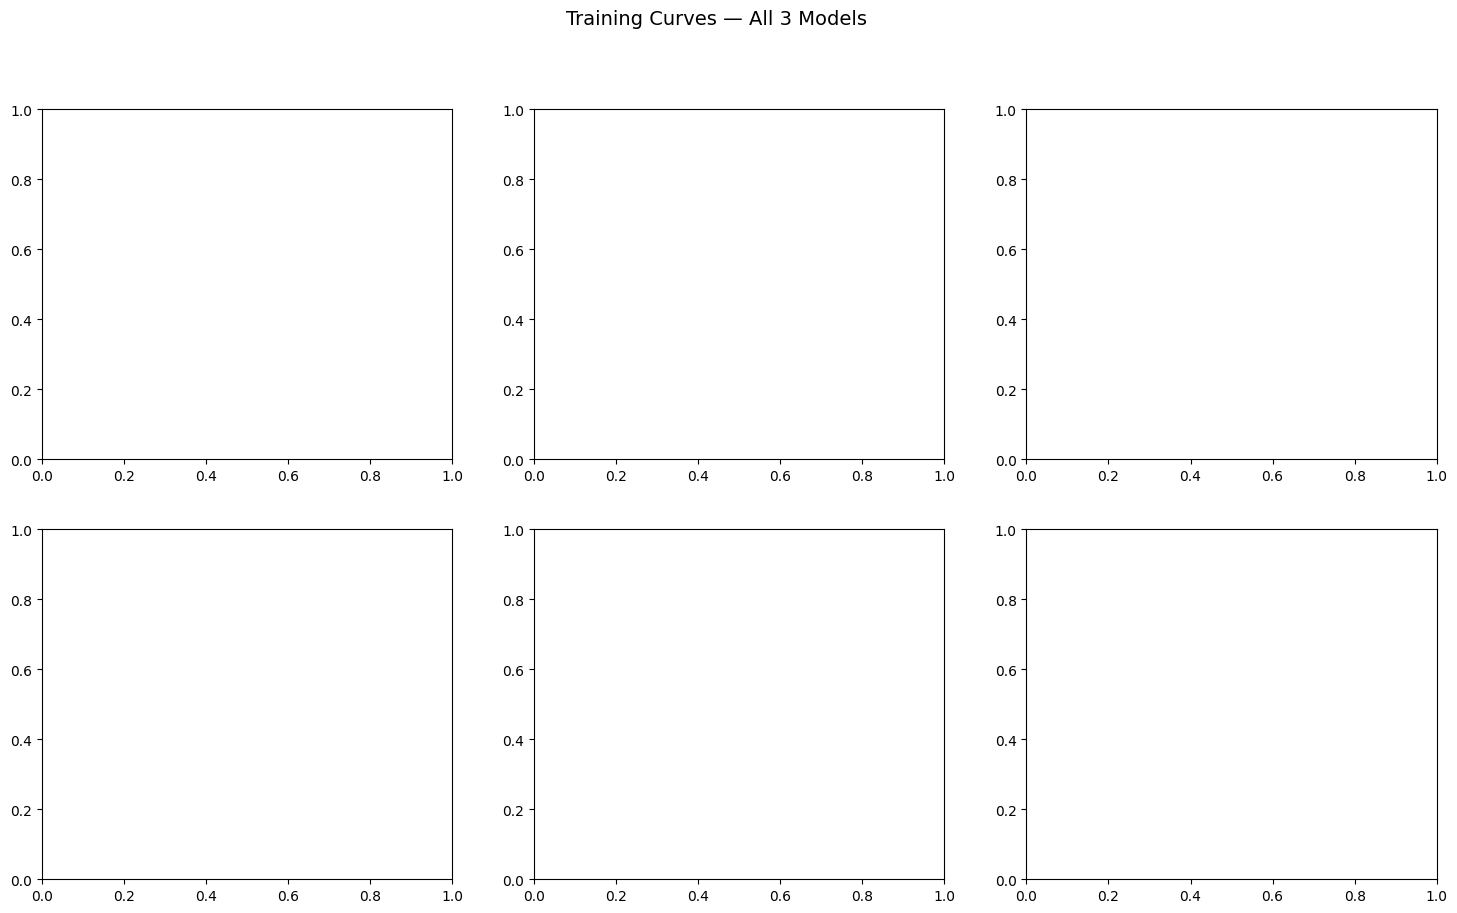

In [ ]:
# =============================================================
# CELL 30 — Plot training and validation curves for all 3 models
# Shows accuracy and loss over epochs
# Saved to Drive results folder
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves — All 3 Models', fontsize=14)

models_history = [
    (history_cnn,      'Model A — CNN'),
    (history_bilstm,   'Model B — CNN+BiLSTM'),
    (history_ensemble, 'Model C — Ensemble')
]

for col, (hist, name) in enumerate(models_history):
    # Accuracy plot
    axes[0][col].plot(hist.history['accuracy'],     label='Train Acc')
    axes[0][col].plot(hist.history['val_accuracy'], label='Val Acc')
    axes[0][col].set_title(f'{name} — Accuracy')
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].set_ylabel('Accuracy')
    axes[0][col].legend()

    # Loss plot
    axes[1][col].plot(hist.history['loss'],     label='Train Loss')
    axes[1][col].plot(hist.history['val_loss'], label='Val Loss')
    axes[1][col].set_title(f'{name} — Loss')
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].set_ylabel('Loss')
    axes[1][col].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✅ Training curves saved to Drive')

In [1]:
# =============================================================
# CELL 31 — Load best saved models from Drive
# ModelCheckpoint saved best weights during training
# We reload them here before evaluation
# =============================================================

from tensorflow.keras.models import load_model

cnn_model      = load_model(os.path.join(MODELS_PATH, 'cnn_model.keras'))
bilstm_model   = load_model(os.path.join(MODELS_PATH, 'bilstm_model.keras'))
ensemble_model = load_model(os.path.join(MODELS_PATH, 'ensemble_model.keras'))

print('✅ All 3 best models loaded from Drive')

NameError: name 'os' is not defined

In [ ]:
# =============================================================
# CELL 32 — Evaluate all 3 models on test set
# Metrics computed:
#   Accuracy    : overall correct predictions
#   Weighted F1 : F1 score weighted by class support
#   AUC-ROC     : area under ROC curve (one-vs-rest)
#   AUC-PRC     : area under Precision-Recall curve
# =============================================================

def evaluate_model(model, X_test, y_test, y_test_cat, model_name):
    """
    Evaluate model on test set and return metrics dictionary.
    """
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')

    # AUC-ROC and AUC-PRC require binarized labels
    y_bin  = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
    auc_roc = roc_auc_score(y_bin, y_pred_prob, average='weighted', multi_class='ovr')
    auc_prc = average_precision_score(y_bin, y_pred_prob, average='weighted')

    print(f'\n{model_name}')
    print(f'  Accuracy    : {acc*100:.2f}%')
    print(f'  Weighted F1 : {f1*100:.2f}%')
    print(f'  AUC-ROC     : {auc_roc*100:.2f}%')
    print(f'  AUC-PRC     : {auc_prc*100:.2f}%')

    return {
        'model'    : model_name,
        'accuracy' : round(acc*100, 2),
        'f1'       : round(f1*100, 2),
        'auc_roc'  : round(auc_roc*100, 2),
        'auc_prc'  : round(auc_prc*100, 2),
        'y_pred'   : y_pred,
        'y_prob'   : y_pred_prob
    }


results_cnn      = evaluate_model(cnn_model,      X_test_cnn, y_test, y_test_cat, 'Model A — CNN')
results_bilstm   = evaluate_model(bilstm_model,   X_test_cnn, y_test, y_test_cat, 'Model B — CNN+BiLSTM')
results_ensemble = evaluate_model(ensemble_model, X_test_cnn, y_test, y_test_cat, 'Model C — Ensemble')


Model A — CNN
  Accuracy    : 90.59%
  Weighted F1 : 90.61%
  AUC-ROC     : 99.15%
  AUC-PRC     : 96.77%

Model B — CNN+BiLSTM
  Accuracy    : 86.70%
  Weighted F1 : 86.71%
  AUC-ROC     : 98.47%
  AUC-PRC     : 94.33%

Model C — Ensemble
  Accuracy    : 90.00%
  Weighted F1 : 90.01%
  AUC-ROC     : 98.99%
  AUC-PRC     : 96.22%


In [ ]:
# =============================================================
# CELL 33 — Print summary comparison table of all 3 models
# Matches the format of Table 4 in the paper
# =============================================================

print('\n' + '='*65)
print(f'{"Model":<25} {"Accuracy":>10} {"F1":>8} {"AUC-ROC":>10} {"AUC-PRC":>10}')
print('='*65)

for res in [results_cnn, results_bilstm, results_ensemble]:
    print(f"{res['model']:<25} {res['accuracy']:>9}% {res['f1']:>7}% {res['auc_roc']:>9}% {res['auc_prc']:>9}%")

print('='*65)


Model                       Accuracy       F1    AUC-ROC    AUC-PRC
Model A — CNN                 90.59%   90.61%     99.15%     96.77%
Model B — CNN+BiLSTM           86.7%   86.71%     98.47%     94.33%
Model C — Ensemble             90.0%   90.01%     98.99%     96.22%


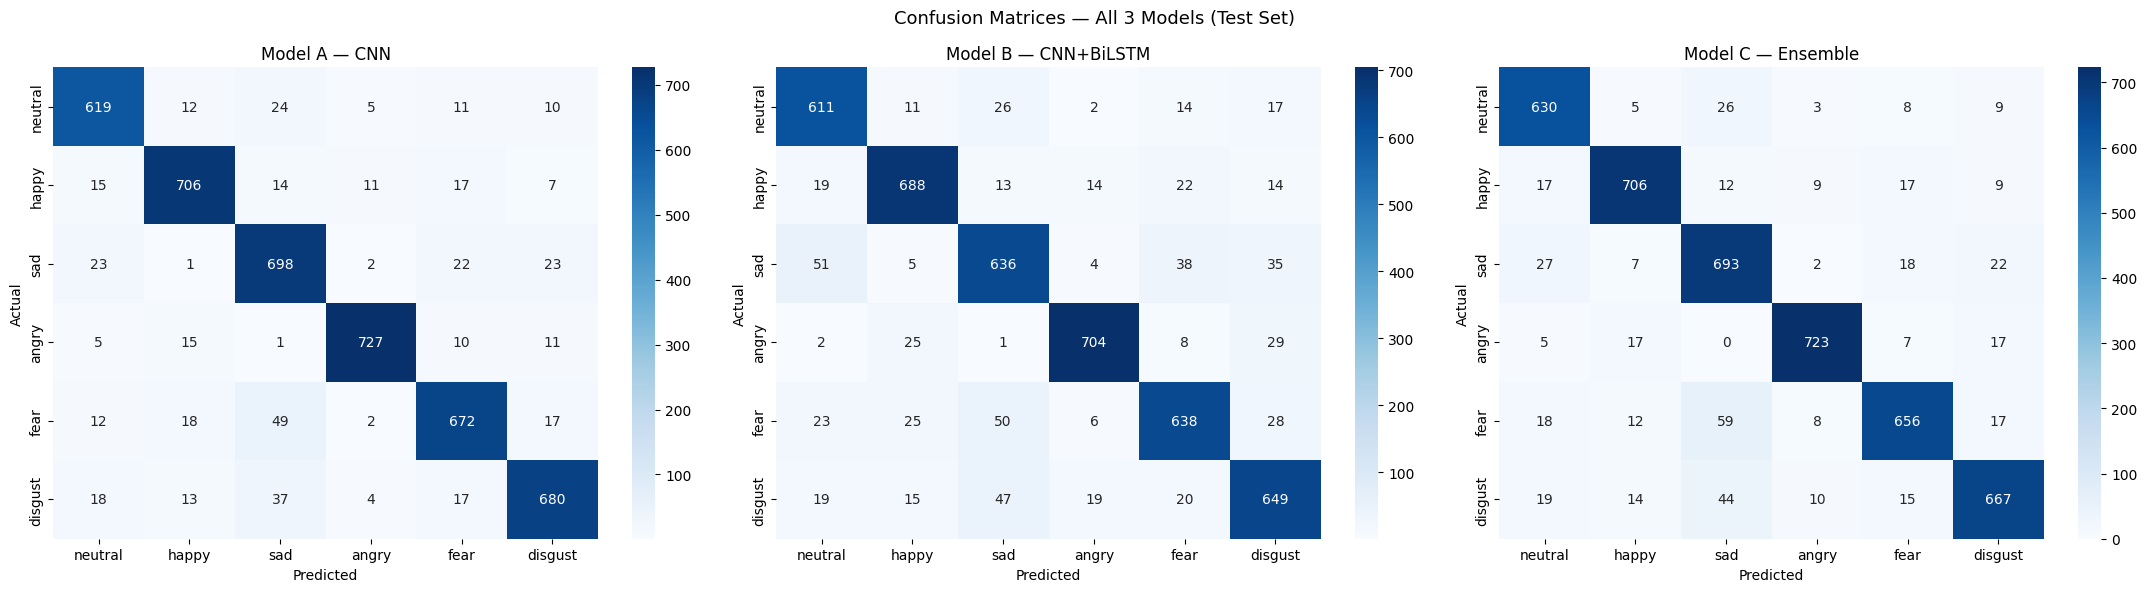

✅ Confusion matrices saved to Drive


In [ ]:
# =============================================================
# CELL 34 — Plot confusion matrices for all 3 models
# Shows which emotions are confused with each other
# Saved to Drive results folder
# =============================================================

emotion_labels = ['neutral','happy','sad','angry','fear','disgust']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Confusion Matrices — All 3 Models (Test Set)', fontsize=13)

for ax, res in zip(axes, [results_cnn, results_bilstm, results_ensemble]):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels = emotion_labels,
        yticklabels = emotion_labels,
        ax          = ax
    )
    ax.set_title(res['model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved to Drive')

In [ ]:
# =============================================================
# CELL 35 — LIME Interpretability on Ensemble Model
# LIME explains individual predictions by perturbing the input
# and observing how the model output changes
# We explain 1 random test sample per emotion class
# to see which feature regions influence each prediction
# =============================================================

from lime import lime_tabular

# Build feature names for LIME
# Matches the order of concatenation in extract_features():
# ZCR(108) + RMSE(108) + MFCC_flat(2160) + Chroma_flat(1296)
feature_names = (
    [f'ZCR_{i}'    for i in range(N_FRAMES)] +
    [f'RMSE_{i}'   for i in range(N_FRAMES)] +
    [f'MFCC_{c}_{i}' for c in range(N_MFCC)   for i in range(N_FRAMES)] +
    [f'Chroma_{c}_{i}' for c in range(N_CHROMA) for i in range(N_FRAMES)]
)

assert len(feature_names) == FEATURE_SIZE, f'Expected {FEATURE_SIZE} feature names'

# LIME explainer uses training data distribution as reference
explainer = lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = feature_names,
    class_names    = emotion_labels,
    mode           = 'classification',
    random_state   = 42
)

# Wrapper: LIME needs a predict function that takes 2D array (no channel dim)
def predict_fn(X_flat):
    X_cnn = X_flat[..., np.newaxis]  # add channel dim back
    return ensemble_model.predict(X_cnn, verbose=0)

print('✅ LIME explainer initialized')
print(f'  Feature names : {len(feature_names)} total')
print(f'  Classes       : {emotion_labels}')

✅ LIME explainer initialized
  Feature names : 3672 total
  Classes       : ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust']


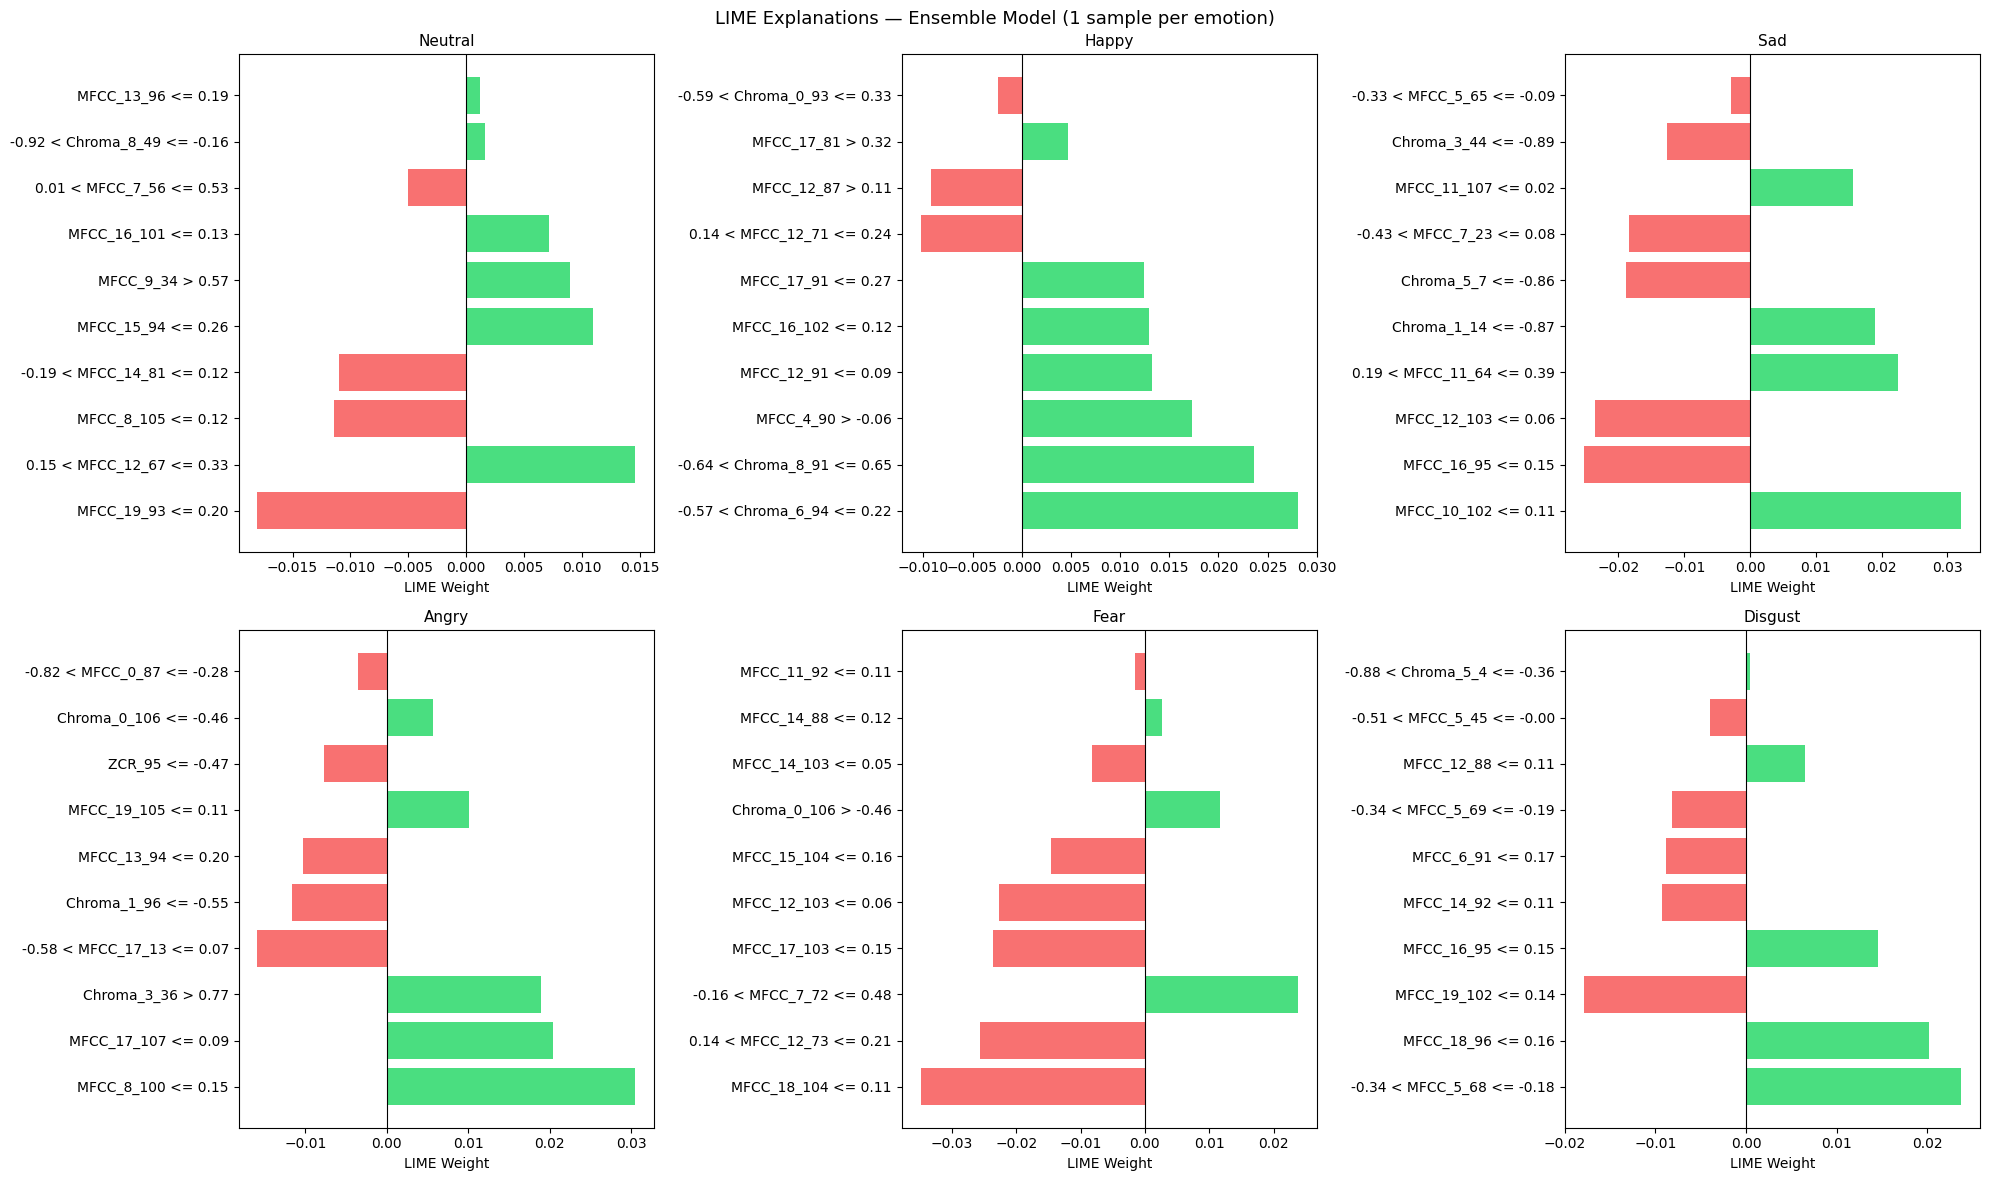

✅ LIME explanations saved to Drive


In [ ]:
# =============================================================
# CELL 36 — Generate and save LIME explanations
# One test sample per emotion class is explained
# Top 10 features shown per explanation
# Plots saved to Drive results folder
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('LIME Explanations — Ensemble Model (1 sample per emotion)', fontsize=13)
axes = axes.flatten()

for class_idx, (emotion_name, ax) in enumerate(zip(emotion_labels, axes)):

    # Find first test sample of this emotion class
    indices = np.where(y_test == class_idx)[0]
    if len(indices) == 0:
        ax.set_title(f'{emotion_name} — no samples')
        continue

    sample_idx = indices[0]
    sample     = X_test[sample_idx]  # flat (3672,)

    # Generate explanation
    explanation = explainer.explain_instance(
        data_row       = sample,
        predict_fn     = predict_fn,
        num_features   = 10,
        labels         = [class_idx]
    )

    # Extract top features and their weights
    exp_list = explanation.as_list(label=class_idx)
    features = [e[0] for e in exp_list]
    weights  = [e[1] for e in exp_list]
    colors   = ['#4ade80' if w > 0 else '#f87171' for w in weights]

    ax.barh(features, weights, color=colors)
    ax.set_title(f'{emotion_name.capitalize()}', fontsize=11)
    ax.set_xlabel('LIME Weight')
    ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'lime_explanations.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✅ LIME explanations saved to Drive')

In [ ]:
# =============================================================
# CELL 37 — Save final results summary to Drive
# Saves all metrics as a text file for easy reference
# =============================================================

summary_path = os.path.join(RESULTS_PATH, 'results_summary.txt')

with open(summary_path, 'w') as f:
    f.write('Speech Emotion Recognition — Iteration 2 Results\n')
    f.write('Speaker-Independent Evaluation\n')
    f.write('='*65 + '\n')
    f.write(f'{"Model":<25} {"Accuracy":>10} {"F1":>8} {"AUC-ROC":>10} {"AUC-PRC":>10}\n')
    f.write('='*65 + '\n')
    for res in [results_cnn, results_bilstm, results_ensemble]:
        f.write(f"{res['model']:<25} {res['accuracy']:>9}% {res['f1']:>7}% {res['auc_roc']:>9}% {res['auc_prc']:>9}%\n")
    f.write('='*65 + '\n')
    f.write('\nDatasets used: RAVDESS, TESS, CREMA-D, SAVEE\n')
    f.write('Features: ZCR + RMSE + MFCC(20) + Chroma(12) = 3672 per sample\n')
    f.write('Split: Speaker-independent (actors held out for test/val)\n')
    f.write('No augmentation applied\n')

print(f'✅ Results summary saved to {summary_path}')
print('\n--- DONE --- All cells completed successfully ---')

✅ Results summary saved to /content/drive/MyDrive/Deep Learning Project/Iteration_2/results/results_summary.txt

--- DONE --- All cells completed successfully ---
